In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil, sys, importlib.util, shutil, tempfile
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import commons, models, utils
from cough_datasets import CoughDatasets, CoughDatasetsCollate


/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


In [2]:

parser = argparse.ArgumentParser()
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")
args = parser.parse_args(["--model_name", "coughdetection_augment"])

model_dir = os.path.join("./logs", args.model_name)
config_save_path = os.path.join(model_dir, "config.json")
with open(config_save_path, "r") as f:
    data = f.read()

config = json.loads(data)
  
hps = utils.HParams(**config)
hps.model_dir = model_dir

temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
spec = importlib.util.spec_from_file_location("model_net", temp_path)
model_net = importlib.util.module_from_spec(spec)
sys.modules["model_net"] = model_net
spec.loader.exec_module(model_net)

pool_net = getattr(model_net, hps.model.pooling_model)
pool_model = pool_net(hps.model.feature_dim, **hps.model)

class CoughDetectionRunner(L.LightningModule):
    def __init__(self, model, hps, class_weights):
        super().__init__()
        self.model = model
        self.hps = hps
        self.class_weights = class_weights

    def forward(self, x, attention_mask=None):
        x = self.model(x, attention_mask=attention_mask)
        return x
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hps.train.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "loss/epoch",
            },
        }

    def on_after_backward(self):
        norm_type = 2
        total_norm = 0
        parameters = list(filter(lambda p: p.grad is not None, self.model.parameters()))
        for p in parameters:
            param_norm = p.grad.data.norm(norm_type)
            total_norm += param_norm.item() ** norm_type
        total_norm = total_norm ** (1. / norm_type)
        self.log("train/grad_norm", total_norm, sync_dist=True)

    def training_step(self, batch, batch_idx):
        _, audio, attention_masks, dse_ids, othr_ids = batch
        
        out_model = self.forward(audio, attention_mask=attention_masks)
        ld = utils.many_loss_category(out_model["disease_logits"], dse_ids, 
                                      loss_type=self.hps.train.loss_function, weights=self.class_weights)
        loss = sum(ld)
        
        self.log("train/loss_step", loss, on_step=True, on_epoch=False, prog_bar=True, logger=True)
        self.logger.experiment.add_scalars('loss', {'train': loss}, self.global_step)
        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx):
        lr = self.optimizers().param_groups[0]["lr"]
        self.log("train/lr", lr, sync_dist=True)

    def validation_step(self, batch, batch_idx):
        _, audio, attention_masks, dse_ids, othr_ids = batch
        
        out_model = self.forward(audio, attention_mask=attention_masks)
        ld = utils.many_loss_category(out_model["disease_logits"], dse_ids, 
                                      loss_type=self.hps.train.loss_function, weights=self.class_weights)

        loss = sum(ld)
        self.logger.experiment.add_scalars('loss', {'valid': loss}, self.global_step)

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_labels = []

    def test_step(self, batch, batch_idx):
        _, audio, attention_masks, dse_ids, _ = batch

        audio = audio.float().squeeze(1)
        attention_masks = attention_masks.float()
        dse_ids = dse_ids.float()

        logits = self(audio, attention_mask=attention_masks)#["disease_logits"]
        preds = torch.argmax(logits, dim=1)
        labels = torch.argmax(dse_ids, dim=1)

        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

    def on_test_epoch_end(self):
        preds = torch.cat(self.test_preds).numpy()
        labels = torch.cat(self.test_labels).numpy()

        cm = confusion_matrix(labels, preds)
        n_classes = cm.shape[0]
        class_labels = [f"Class {i+1}" for i in range(n_classes)]

        acc = accuracy_score(labels, preds)
        b_acc = balanced_accuracy_score(labels, preds)

        sens = np.mean([
            cm[i, i] / cm[i, :].sum()
            for i in range(n_classes) if cm[i, :].sum() > 0
        ])

        spec = np.mean([
            (cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]) /
            (cm.sum() - cm[i, :].sum())
            for i in range(n_classes) if (cm.sum() - cm[i, :].sum()) > 0
        ])

        # Log metrics
        self.log("test_acc", acc, sync_dist=True)
        self.log("test_bacc", b_acc, sync_dist=True)
        self.log("test_sens", sens, sync_dist=True)
        self.log("test_spec", spec, sync_dist=True)

        # Export confusion matrix if needed
        if hasattr(self.hparams, "model_dir"):
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=class_labels, yticklabels=class_labels)
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix")
            plt.savefig(f"{self.hparams.model_dir}/result_cm.png")
            plt.close()

        return {
            "acc": acc,
            "bacc": b_acc,
            "sens": sens,
            "spec": spec,
        }

runner_lightning = CoughDetectionRunner(pool_model, hps=hps, class_weights=[])
runner_lightning = CoughDetectionRunner.load_from_checkpoint(
    "/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/logs/coughdetection_augment/best_model.ckpt",
    model=pool_model,
    hps=hps,                 
    class_weights=[]
)
runner_lightning.eval()
trainer = L.Trainer(
       max_epochs=1000,
       accelerator="gpu" if torch.cuda.is_available() else "cpu",
       devices="auto",
       default_root_dir=hps.model_dir
    )

df_train = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.train')
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/{hps.data.metadata_csv}.test')

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train = df_train[hps.data.column_order]
df_test = df_test[hps.data.column_order]

collate_fn = CoughDatasetsCollate(hps.data.many_class)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [3]:
test_dataset = CoughDatasets(df_test.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_1.pickle", train=False)
test_loader = DataLoader(test_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

results = trainer.test(runner_lightning, dataloaders=test_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9783878326416016     │
│         test_bacc         │    0.9728837013244629     │
│         test_sens         │    0.9728837013244629     │
│         test_spec         │    0.9728837013244629     │
└───────────────────────────┴───────────────────────────┘

In [5]:
dummy = torch.randn(1, 240, 240)
dummy = dummy.to(torch.float32)#.cuda()

torch.onnx.export(
    runner_lightning.model.cpu(),
    dummy,
    f"/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/pretrained/mycough_detection.onnx",
    opset_version=18,               
    do_constant_folding=True,
    input_names=["audio"],
    output_names=["logits"],
    dynamic_axes={
        "audio": {0: "batch"},   # only batch is dynamic
        "logits": {0: "batch"},  # only batch is dynamic
    },
)


/tmp/ipykernel_1275267/2714844369.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `Eff_MyOwn1([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Eff_MyOwn1([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 115 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.9.1+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"audio"<FLOAT,[s77,240,240]>
            ),
            outputs=(
                %"logits"<FLOAT,[1,2]>
            ),
            initializers=(
                %"cnn1.weight"<FLOAT,[3,1,3,3]>{TorchTensor(...)},
                %"cnn1.bias"<FLOAT,[3]>{TorchTensor<FLOAT,[3]>(Parameter containing: tensor([ 0.2927, -0.2462, -0.2669], requires_grad=True), name='cnn1.bias')},
                %"efficientnet._conv_stem.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"efficientnet._blocks.0._depthwise_conv.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"efficientnet._blocks.0._se_reduce.weight"<FLOAT,[8,32,1,1]>{TorchTensor(...)},
                %"eff

In [9]:
import glob, torch, librosa, torchaudio, webrtcvad, random

import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd
import torch.nn.functional as F
import onnxruntime as ort
import pickle as pk

from tqdm import tqdm
from pathlib import Path
from scipy.ndimage import zoom

def pre_process_audio_mel(audio, sample_rate=16000, n_mels=128, f_min=0.0, f_max=8000.0, nfft=1024, hop=256):
    audio = (audio - wav_mean) / (wav_std + 1e-6)
    S = librosa.feature.melspectrogram(
        y=audio.astype(np.float32),
        sr=sample_rate,
        n_mels=n_mels,
        fmin=f_min,
        fmax=f_max,
        n_fft=nfft,
        hop_length=hop,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=1.0).astype(np.float32) #.T.astype(np.float32)  # transpose -> (time, mel)

    t = torch.from_numpy(S_db).unsqueeze(0).unsqueeze(0)  # (1,1,time,mel)
    t = F.interpolate(t, size=(240, 240), mode="bilinear", align_corners=False)
    return t.squeeze(0).squeeze(0).contiguous()

def webrtc_silence_mask(y, sr=16000, frame_duration_ms=30, aggressiveness=2):
    vad = webrtcvad.Vad(aggressiveness)
    frame_len = int(sr * frame_duration_ms / 1000)
    num_frames = len(y) // frame_len

    mask = np.zeros(len(y), dtype=bool)
    for i in range(num_frames):
        frame = y[i * frame_len:(i + 1) * frame_len]
        pcm = (frame * 32768).astype(np.int16).tobytes()
        if vad.is_speech(pcm, sr):
            start = max(0, (i - 4) * frame_len)
            end = min(len(y), (i + 4) * frame_len)
            mask[start:end] = True
    return mask

ONNX_SESSION = ort.InferenceSession(f"{hps.model_dir}/cough_model.onnx", providers=["CPUExecutionProvider"])
input_name = ONNX_SESSION.get_inputs()[0].name
output_name = ONNX_SESSION.get_outputs()[0].name

with open(f"{hps.model_dir}/wav_stats_fold_1.pickle", 'rb') as f:
    stats = pk.load(f)
    wav_mean, wav_std = stats["mean_db"], stats["std_db"]

SR_MODEL = 16000
stride_ratio = 0.2
window_samples = int(0.5 * SR_MODEL)
pad_len = int(0.0 * SR_MODEL)
stride = int(window_samples * stride_ratio)
min_len_segment = int(0.3 * SR_MODEL)
cough_padding = int(0.2 * SR_MODEL)
audio_len = window_samples - pad_len

threshold = 0.95

/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
def extract_cough_segments(
    path,
    audio_len=16000,
    stride=8000,
    threshold=0.5,
    cough_padding=1600,
    min_len_segment=4800,
):
    # Load mono audio efficiently
    y, sr = librosa.load(path, sr=SR_MODEL, mono=True)
    silence_len = int(0.1 * sr)
    silence_energy = ((np.mean(y[:silence_len] ** 2) + np.mean(y[-silence_len:] ** 2)) / 2)
    thresh_silence = silence_energy * 1.5

    speech_mask = webrtc_silence_mask(y, sr)
    silence_audio = y[~speech_mask]
    speech_audio = y[speech_mask]

    if len(speech_audio) < audio_len:
        return [], np.concatenate((speech_audio, silence_audio))

    # Precompute start indices once
    starts = np.arange(0, len(speech_audio) - audio_len + 1, stride)
    n_win = len(starts)
    if n_win == 0:
        return [], np.concatenate((speech_audio, silence_audio))

    # Batch preprocessing in a single loop to minimize RAM spikes
    processed = np.empty((n_win, *pre_process_audio_mel(np.zeros(audio_len), f_max=8000).shape), dtype=np.float32)
    for i, s in enumerate(starts):
        processed[i] = pre_process_audio_mel(speech_audio[s:s + audio_len], f_max=8000)

    # Run inference in smaller batches to reduce memory footprint
    batch_size = 8 
    cough_probs = []
    for i in range(0, n_win, batch_size):
        batch = processed[i:i + batch_size]
        raw_pred = ONNX_SESSION.run([output_name], {input_name: batch})[0]
        # use np softmax to avoid torch overhead
        exp = np.exp(raw_pred - np.max(raw_pred, axis=-1, keepdims=True))
        softmax = exp / exp.sum(axis=-1, keepdims=True)
        cough_probs.extend(softmax[:, 1])

    cough_probs = np.array(cough_probs)
    mask = cough_probs > threshold

    # Fast mask filling (vectorized)
    sample_mask = np.zeros(len(speech_audio), dtype=bool)
    for s in starts[mask]:
        e = min(s + audio_len, len(speech_audio))
        sample_mask[s:e] = True

    # Segment boundaries
    diff = np.diff(sample_mask.astype(np.int8))
    start_idxs = np.flatnonzero(diff == 1) + 1
    end_idxs = np.flatnonzero(diff == -1) + 1
    if sample_mask[0]:
        start_idxs = np.insert(start_idxs, 0, 0)
    if sample_mask[-1]:
        end_idxs = np.append(end_idxs, len(sample_mask))

    # Extract segments
    segments = []
    for s, e in zip(start_idxs, end_idxs):
        e = min(e + cough_padding, len(speech_audio))
        if e - s >= min_len_segment and np.mean(np.copy(speech_audio[s:e]) ** 2) > thresh_silence:
            segments.append(np.copy(speech_audio[s:e]))

    # Non-cough aggregation
    non_cough_audio = np.concatenate((speech_audio[~sample_mask], silence_audio))
    return segments, non_cough_audio, speech_audio, sample_mask


In [12]:
wav_files = glob.glob("/run/media/fourier/Data1/Pras/DatabaseLLM/cirdz/Chawama Phone B/Chawama Phone B/*.wav", recursive=True)
path = random.choice(wav_files)

2025-11-27 01:46:24.020184228 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,2} does not match actual shape of {222,2} for output logits


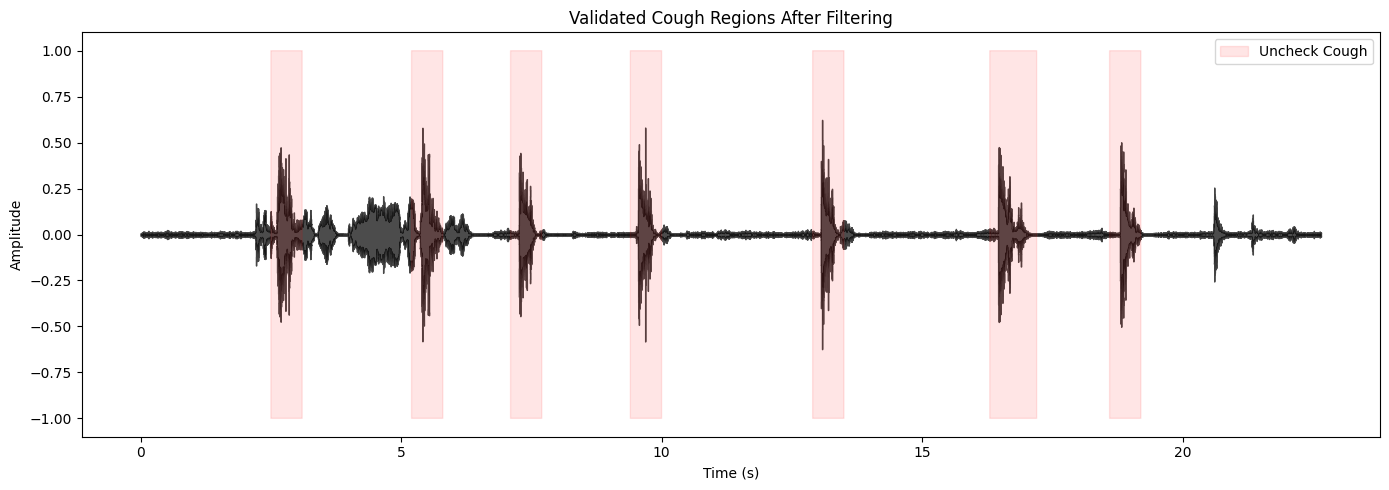

In [13]:
y, sr = librosa.load(path, sr=SR_MODEL)
speech_mask = webrtc_silence_mask(y, sr)
silence_mask = ~speech_mask

speech_audio = y[speech_mask]
silence_audio = y[~speech_mask]

windows = []
for start in range(0, len(speech_audio) - audio_len + 1, stride):
    seg_audio = speech_audio[start:start + audio_len]
    windows.append(seg_audio)

processed = [pre_process_audio_mel(w, f_max=8000) for w in windows]
batch_input = np.stack(processed, axis=0)

raw_predictions = ONNX_SESSION.run([output_name], {input_name: batch_input})[0]
probs = F.softmax(torch.from_numpy(raw_predictions), dim=-1).numpy()
cough_probs = probs[:, 1]
mask = cough_probs > threshold

sample_mask = np.zeros_like(speech_audio, dtype=bool)
for i, start in enumerate(range(0, len(speech_audio) - audio_len + 1, stride)):
    if bool(mask[i]):
        sample_mask[start:start + audio_len] = True

segments = []
in_segment = False
start_idx = 0
for i, val in enumerate(sample_mask):
    if val and not in_segment:
        in_segment = True
        start_idx = i
    elif not val and in_segment:
        in_segment = False
        end_idx = i + cough_padding
        seg_len = end_idx - start_idx
        if seg_len >= min_len_segment:
            segment = speech_audio[start_idx:end_idx].copy()
            segments.append(segment)
if in_segment:
    end_idx = len(sample_mask)
    seg_len = end_idx - start_idx
    if seg_len >= min_len_segment:
        segment = speech_audio[start_idx:end_idx].copy()
        segments.append(segment)

time = np.arange(len(speech_audio)) / SR_MODEL
plt.figure(figsize=(14, 5))
librosa.display.waveshow(speech_audio, sr=SR_MODEL, color="black", alpha=0.7)
#plt.fill_between(time, -1, 1, where=valid_mask, color="green", alpha=0.6, label="Validated Cough")
plt.fill_between(time, -1, 1, where=sample_mask, color="red", alpha=0.1, label="Uncheck Cough")
plt.title("Validated Cough Regions After Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()